CUDA device: Tesla T4


100%|██████████| 170M/170M [13:25<00:00, 212kB/s]


seed=7 epoch=001 loss=2.2964 val=0.3290
seed=7 epoch=002 loss=1.6870 val=0.5280
seed=7 epoch=003 loss=1.3992 val=0.5820
seed=7 epoch=004 loss=1.2312 val=0.6934
seed=7 epoch=005 loss=1.1027 val=0.6632
seed=7 epoch=006 loss=1.0173 val=0.7786
seed=7 epoch=007 loss=0.9660 val=0.7850
seed=7 epoch=008 loss=0.9305 val=0.7672
seed=7 epoch=009 loss=0.8968 val=0.7866
seed=7 epoch=010 loss=0.8815 val=0.7324
seed=7 epoch=011 loss=0.8641 val=0.7204
seed=7 epoch=012 loss=0.8501 val=0.8352
seed=7 epoch=013 loss=0.8376 val=0.7468
seed=7 epoch=014 loss=0.8336 val=0.7594
seed=7 epoch=015 loss=0.8187 val=0.7700
seed=7 epoch=016 loss=0.8161 val=0.8354
seed=7 epoch=017 loss=0.8086 val=0.8264
seed=7 epoch=018 loss=0.8036 val=0.8210
seed=7 epoch=019 loss=0.7959 val=0.8336
seed=7 epoch=020 loss=0.7881 val=0.8212
seed=7 epoch=021 loss=0.7853 val=0.8158
seed=7 epoch=022 loss=0.7816 val=0.8332
seed=7 epoch=023 loss=0.7758 val=0.7678
seed=7 epoch=024 loss=0.7749 val=0.8044
seed=7 epoch=025 loss=0.7689 val=0.8272


,seed,best_epoch,validation_accuracy,test_accuracy
0,7,194,0.9536,0.9513
1,17,186,0.9516,0.9502
2,27,189,0.9494,0.9548


,metric,mean,sd
0,validation_accuracy,0.951533,0.002101
1,test_accuracy,0.952100,0.002402


,Item,Value
0,Data split,"45,000 train / 5,000 validation / 10,000 test"
1,Architecture,CIFAR-adapted ResNet-18
2,Stem,"3×3 convolution, stride 1, no max-pooling"
3,Normalization,CIFAR-10 channel mean and standard deviation
4,Augmentation,Random crop with padding 4 and horizontal flip
5,Optimizer,SGD with Nesterov momentum
6,Initial learning rate,0.1
7,Schedule,Cosine annealing
8,Momentum,0.9
9,Weight decay,5×10⁻⁴


,sigma,test_accuracy,excir_spearman_vs_clean,excir_top8_jaccard
0,0.00,0.9513,1.0,1.0
1,0.01,0.9501,1.0,1.0
2,0.03,0.9467,1.0,1.0
3,0.05,0.9397,1.0,1.0
4,0.10,0.8985,1.0,1.0


,token,local_excir,global_excir,tfidf
0,team,0.004669,0.079393,0.058807
1,baltimore,0.002517,0.004952,0.508314
2,fan,0.001984,0.022922,0.086573
3,care,0.000835,0.009650,0.086573
4,used,0.000769,0.010553,0.072911
5,place,0.000692,0.008568,0.080725
6,came,0.000574,0.006866,0.083543
7,orioles,0.000506,0.001137,0.444482
8,base,0.000482,0.005549,0.086827
9,father,0.000475,0.001725,0.275703


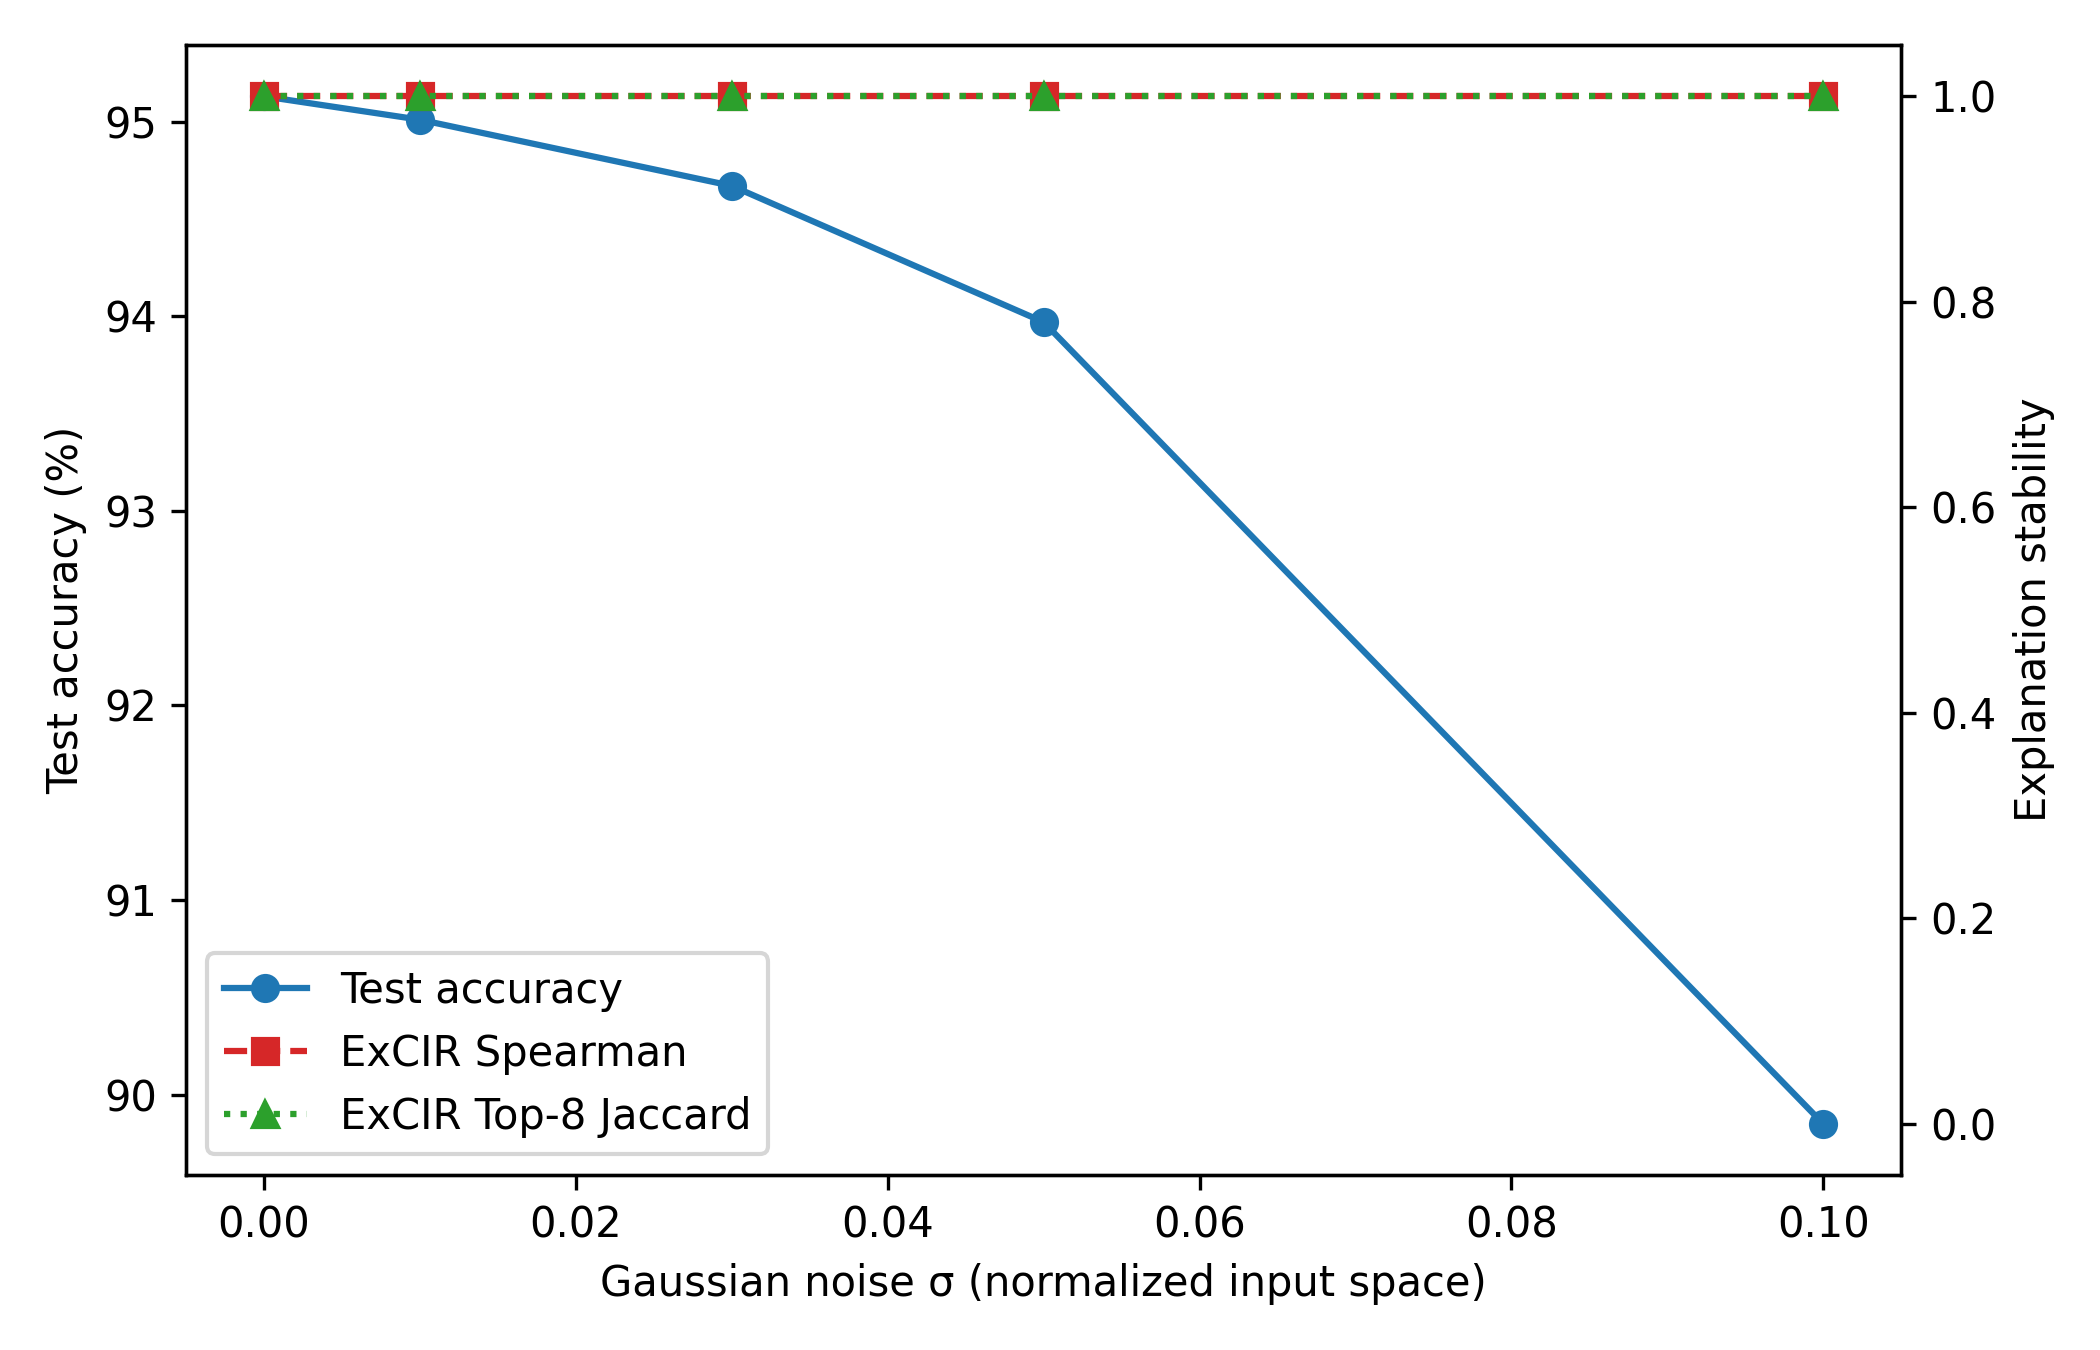

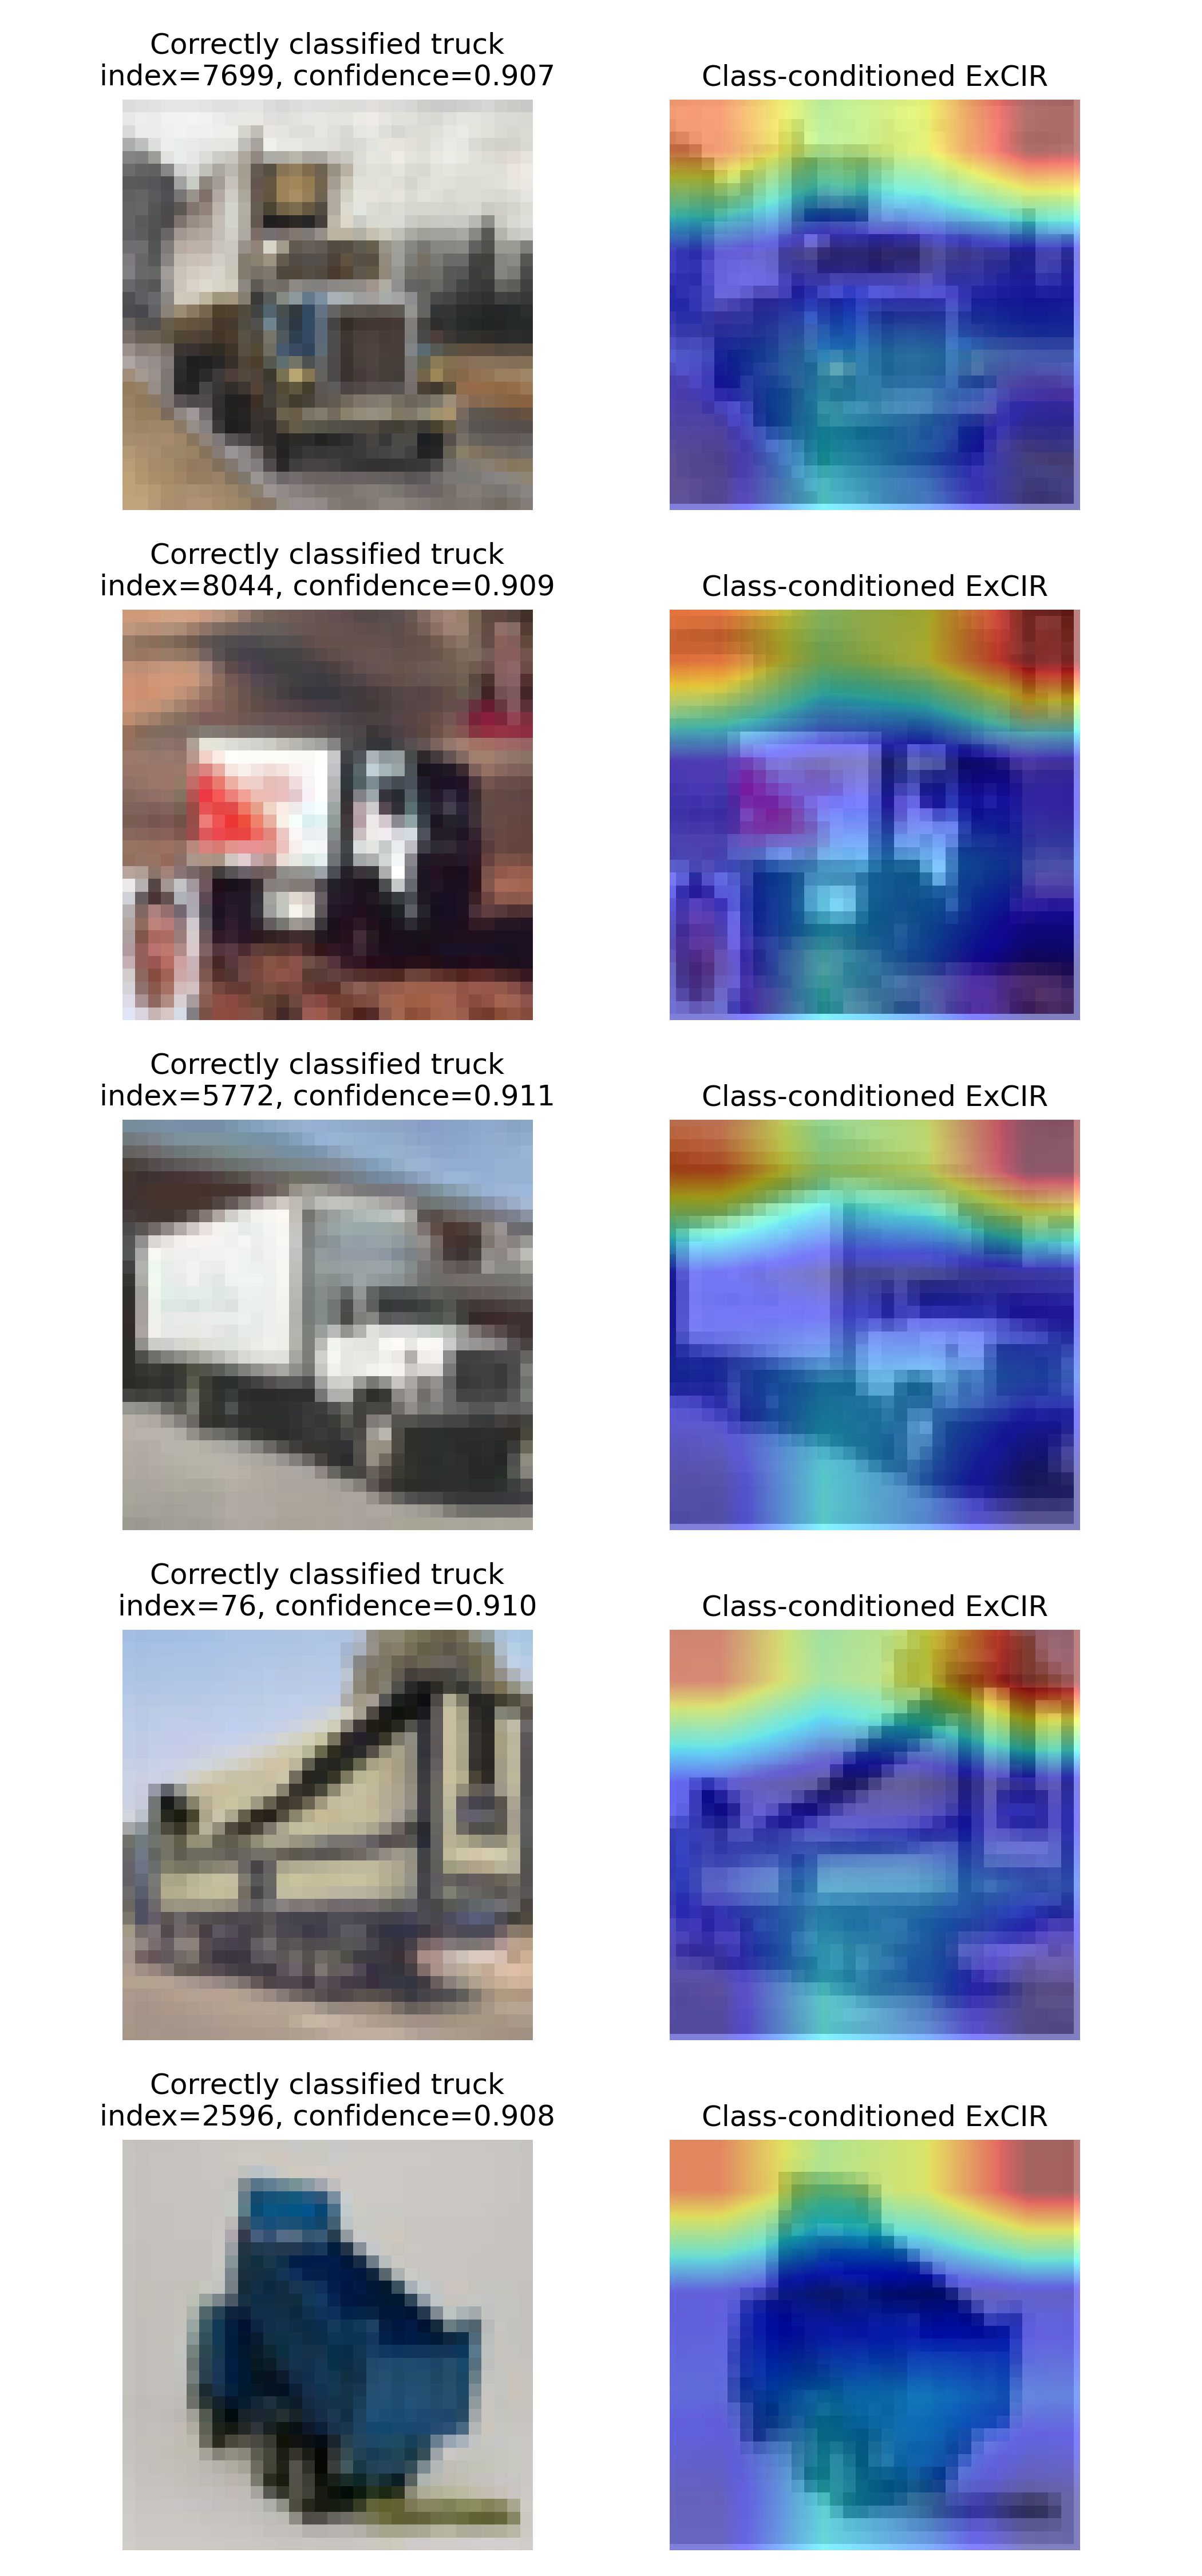

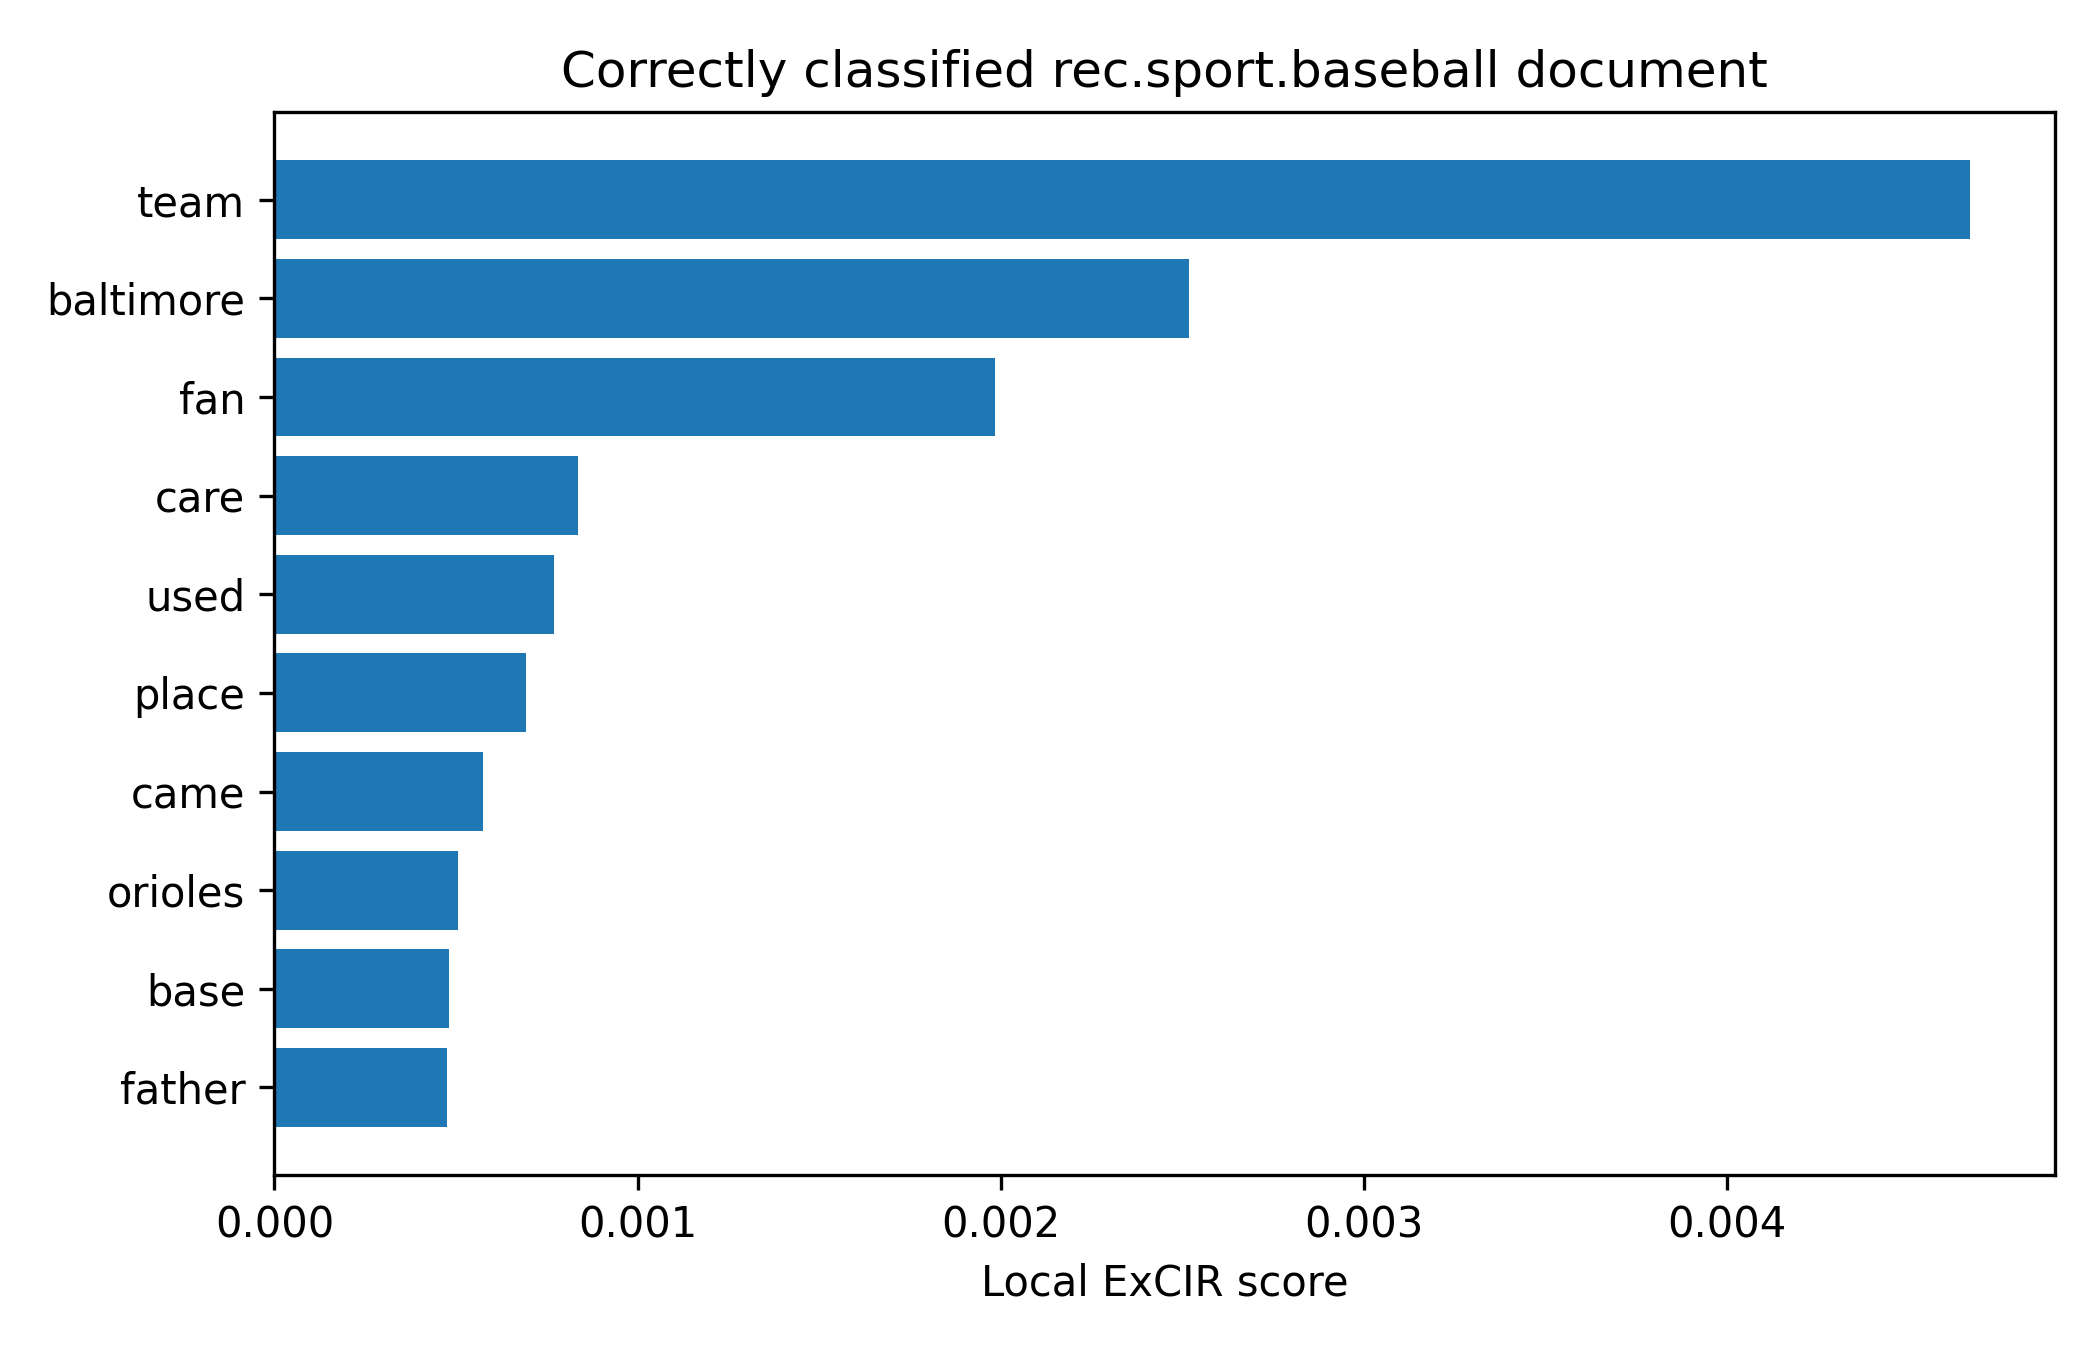

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# SINGLE COLAB CELL — COMPLETE REVIEWER 2 EXPERIMENT

import os, json, random, shutil, subprocess, html, re
from pathlib import Path

subprocess.check_call([
    "pip", "install", "-q", "numpy", "pandas", "scipy",
    "scikit-learn", "matplotlib", "torch", "torchvision"
])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from scipy.stats import spearmanr
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet18
from IPython.display import Image, HTML, display
from google.colab import files

# ============================================================
# CONFIGURATION
# ============================================================

DATA = Path("/content/data")
OUT = Path("/content/results")
DATA.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)

SEEDS = [7, 17, 27]
EPOCHS = 200
BATCH_SIZE = 128
WORKERS = 2
SIGMAS = [0.00, 0.01, 0.03, 0.05, 0.10]
GRID = 4
TOPK = 8
ATTRIBUTION_SAMPLES = 5000
TRUCK_CLASS = 9

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable. In Colab select Runtime > Change runtime type > T4 GPU."
    )
DEVICE = torch.device("cuda:0")
torch.cuda.set_device(0)
torch.set_float32_matmul_precision("high")
print("CUDA device:", torch.cuda.get_device_name(0))

CIFAR_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
STD = np.array([0.2470, 0.2435, 0.2616], dtype=np.float32)

# ============================================================
# REPRODUCIBILITY
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ============================================================
# CORRECTED CIR: SQUARED NORMALIZED COVARIANCE
# ============================================================

def cir_score_1d(x, y, eps=1e-12):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)

    xc = x - x.mean()
    yc = y - y.mean()

    numerator = np.dot(xc, yc) ** 2
    denominator = np.dot(xc, xc) * np.dot(yc, yc)

    if denominator <= eps:
        return 0.0

    return float(np.clip(numerator / denominator, 0.0, 1.0))


def excir_scores(X, Y):
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64).reshape(-1)

    return np.array([
        cir_score_1d(X[:, j], Y)
        for j in range(X.shape[1])
    ])


def topk_jaccard(a, b, k):
    aa = set(np.argsort(a.ravel())[-k:])
    bb = set(np.argsort(b.ravel())[-k:])
    return len(aa & bb) / max(len(aa | bb), 1)

# ============================================================
# CIFAR-10 DATA
# ============================================================

def make_loaders(seed):
    normalize = transforms.Normalize(MEAN.tolist(), STD.tolist())

    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize,
    ])

    evaluation_transform = transforms.Compose([
        transforms.ToTensor(),
        normalize,
    ])

    raw_train = datasets.CIFAR10(
        DATA, train=True, download=True
    )

    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(
        len(raw_train), generator=generator
    ).tolist()

    train_indices = indices[:45000]
    validation_indices = indices[45000:]

    train_dataset = Subset(
        datasets.CIFAR10(
            DATA, train=True, transform=train_transform
        ),
        train_indices,
    )

    validation_dataset = Subset(
        datasets.CIFAR10(
            DATA, train=True, transform=evaluation_transform
        ),
        validation_indices,
    )

    test_dataset = datasets.CIFAR10(
        DATA, train=False, transform=evaluation_transform,
        download=True,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=WORKERS,
        pin_memory=True,
        persistent_workers=WORKERS > 0,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=WORKERS,
        pin_memory=True,
        persistent_workers=WORKERS > 0,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=WORKERS,
        pin_memory=True,
        persistent_workers=WORKERS > 0,
    )

    return (
        train_loader,
        validation_loader,
        test_loader,
        test_dataset,
    )

# ============================================================
# CIFAR-ADAPTED RESNET-18
# ============================================================

def make_model():
    model = resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(
        3, 64, kernel_size=3, stride=1,
        padding=1, bias=False
    )
    model.maxpool = nn.Identity()
    return model


@torch.inference_mode()
def evaluate(model, loader, sigma=0.0):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if sigma > 0:
            images = images + sigma * torch.randn_like(images)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.numel()

    return correct / total


def train_seed(seed):
    set_seed(seed)

    train_loader, val_loader, test_loader, _ = make_loaders(seed)
    model = make_model().to(DEVICE)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=5e-4,
        nesterov=True,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler = torch.amp.GradScaler("cuda")

    best_accuracy = -1
    best_epoch = 0
    checkpoint = OUT / f"resnet18_seed{seed}.pt"
    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0
        total_samples = 0

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                loss = criterion(model(images), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

        scheduler.step()
        validation_accuracy = evaluate(model, val_loader)

        history.append({
            "seed": seed,
            "epoch": epoch,
            "train_loss": total_loss / total_samples,
            "validation_accuracy": validation_accuracy,
            "learning_rate": scheduler.get_last_lr()[0],
        })

        if validation_accuracy > best_accuracy:
            best_accuracy = validation_accuracy
            best_epoch = epoch

            torch.save({
                "model": model.state_dict(),
                "seed": seed,
                "epoch": epoch,
                "validation_accuracy": validation_accuracy,
            }, checkpoint)

        print(
            f"seed={seed} epoch={epoch:03d} "
            f"loss={total_loss/total_samples:.4f} "
            f"val={validation_accuracy:.4f}"
        )

    state = torch.load(checkpoint, map_location=DEVICE)
    model.load_state_dict(state["model"])
    test_accuracy = evaluate(model, test_loader)

    pd.DataFrame(history).to_csv(
        OUT / f"training_history_seed{seed}.csv",
        index=False,
    )

    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "validation_accuracy": best_accuracy,
        "test_accuracy": test_accuracy,
    }

# ============================================================
# TRAIN THREE SEEDS
# ============================================================

seed_results = [train_seed(seed) for seed in SEEDS]
seed_results = pd.DataFrame(seed_results)

seed_results.to_csv(
    OUT / "cifar_seed_results.csv", index=False
)

accuracy_summary = pd.DataFrame([
    {
        "metric": "validation_accuracy",
        "mean": seed_results.validation_accuracy.mean(),
        "sd": seed_results.validation_accuracy.std(ddof=1),
    },
    {
        "metric": "test_accuracy",
        "mean": seed_results.test_accuracy.mean(),
        "sd": seed_results.test_accuracy.std(ddof=1),
    },
])

accuracy_summary.to_csv(
    OUT / "cifar_accuracy_mean_sd.csv", index=False
)

# ============================================================
# TRAINING-RECIPE TABLE
# ============================================================

recipe = pd.DataFrame([
    ["Data split", "45,000 train / 5,000 validation / 10,000 test"],
    ["Architecture", "CIFAR-adapted ResNet-18"],
    ["Stem", "3×3 convolution, stride 1, no max-pooling"],
    ["Normalization", "CIFAR-10 channel mean and standard deviation"],
    ["Augmentation", "Random crop with padding 4 and horizontal flip"],
    ["Optimizer", "SGD with Nesterov momentum"],
    ["Initial learning rate", "0.1"],
    ["Schedule", "Cosine annealing"],
    ["Momentum", "0.9"],
    ["Weight decay", "5×10⁻⁴"],
    ["Batch size", "128"],
    ["Epochs", "200"],
    ["Seeds", "7, 17, 27"],
    ["Selection", "Highest clean validation accuracy"],
    ["Training noise", "None"],
    ["Robustness noise", "Evaluation only after model freezing"],
], columns=["Item", "Value"])

recipe.to_csv(OUT / "training_recipe.csv", index=False)

with open(OUT / "training_recipe.tex", "w") as file:
    file.write(recipe.to_latex(
        index=False,
        caption="CIFAR-10 ResNet-18 training recipe.",
        label="tab:cifar_recipe",
    ))

# ============================================================
# LOAD SEED-7 MODEL
# ============================================================

_, _, test_loader, test_dataset = make_loaders(7)

model = make_model().to(DEVICE)
state = torch.load(
    OUT / "resnet18_seed7.pt",
    map_location=DEVICE,
)
model.load_state_dict(state["model"])
model.eval()

# ============================================================
# PATCH FEATURES
# ============================================================

def patch_features(images):
    n, c, h, w = images.shape
    patch_h = h // GRID
    patch_w = w // GRID

    return (
        images.reshape(
            n, c, GRID, patch_h, GRID, patch_w
        )
        .mean(dim=(3, 5))
        .permute(0, 2, 3, 1)
        .reshape(n, -1)
    )


@torch.inference_mode()
def collect_excir_data(sigma):
    feature_batches = []
    probability_batches = []
    count = 0

    for images, _ in test_loader:
        images = images.to(DEVICE, non_blocking=True)

        if sigma > 0:
            images = images + sigma * torch.randn_like(images)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            probabilities = model(images).softmax(dim=1)[:, TRUCK_CLASS]

        feature_batches.append(
            patch_features(images).cpu()
        )
        probability_batches.append(
            probabilities.cpu()
        )

        count += len(images)

        if count >= ATTRIBUTION_SAMPLES:
            break

    X = torch.cat(feature_batches)[:ATTRIBUTION_SAMPLES].numpy()
    Y = torch.cat(probability_batches)[:ATTRIBUTION_SAMPLES].numpy()

    channel_scores = excir_scores(X, Y)

    return channel_scores.reshape(GRID, GRID, 3).mean(axis=2)

# ============================================================
# NOISE-INTENSITY EXPERIMENT
# ============================================================

noise_rows = []
noise_maps = {}

for sigma in SIGMAS:
    set_seed(7 + int(sigma * 10000))

    test_accuracy = evaluate(
        model, test_loader, sigma=sigma
    )

    score_map = collect_excir_data(sigma)
    noise_maps[sigma] = score_map

    noise_rows.append({
        "sigma": sigma,
        "test_accuracy": test_accuracy,
    })

clean_scores = noise_maps[0.0]

for row in noise_rows:
    current = noise_maps[row["sigma"]]

    row["excir_spearman_vs_clean"] = float(
        spearmanr(
            clean_scores.ravel(),
            current.ravel(),
        ).statistic
    )

    row["excir_top8_jaccard"] = topk_jaccard(
        clean_scores,
        current,
        TOPK,
    )

noise_results = pd.DataFrame(noise_rows)
noise_results.to_csv(
    OUT / "cifar_noise_stability.csv",
    index=False,
)

fig, axis1 = plt.subplots(figsize=(7, 4.5))
axis2 = axis1.twinx()

axis1.plot(
    noise_results.sigma,
    noise_results.test_accuracy * 100,
    "o-",
    color="tab:blue",
    label="Test accuracy",
)

axis2.plot(
    noise_results.sigma,
    noise_results.excir_spearman_vs_clean,
    "s--",
    color="tab:red",
    label="ExCIR Spearman",
)

axis2.plot(
    noise_results.sigma,
    noise_results.excir_top8_jaccard,
    "^:",
    color="tab:green",
    label="ExCIR Top-8 Jaccard",
)

axis1.set_xlabel("Gaussian noise σ (normalized input space)")
axis1.set_ylabel("Test accuracy (%)")
axis2.set_ylabel("Explanation stability")
axis2.set_ylim(-0.05, 1.05)

all_lines = axis1.lines + axis2.lines
axis1.legend(
    all_lines,
    [line.get_label() for line in all_lines],
    loc="lower left",
)

fig.tight_layout()
fig.savefig(
    OUT / "cifar_noise_stability.png",
    dpi=300,
)
plt.close(fig)

# ============================================================
# CIFAR TRUCK VISUALIZATIONS
# ============================================================

def denormalize(image):
    image = image.permute(1, 2, 0).cpu().numpy()
    return np.clip(image * STD + MEAN, 0, 1)


clean_map = clean_scores / (clean_scores.max() + 1e-12)
rng = np.random.default_rng(7)
selected = []

for index in rng.permutation(len(test_dataset)):
    image, true_class = test_dataset[int(index)]

    with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
        probabilities = model(
            image.unsqueeze(0).to(DEVICE, non_blocking=True)
        ).softmax(dim=1)[0]

    predicted_class = probabilities.argmax().item()

    if true_class == TRUCK_CLASS and predicted_class == TRUCK_CLASS:
        selected.append((
            image,
            probabilities[TRUCK_CLASS].item(),
            int(index),
        ))

    if len(selected) == 5:
        break

fig, axes = plt.subplots(
    len(selected), 2,
    figsize=(7, 3 * len(selected)),
)

for row, (image, confidence, index) in enumerate(selected):
    rgb = denormalize(image)

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(
        f"Correctly classified truck\n"
        f"index={index}, confidence={confidence:.3f}"
    )

    axes[row, 1].imshow(rgb)
    axes[row, 1].imshow(
        clean_map,
        cmap="jet",
        alpha=0.50,
        interpolation="bilinear",
        extent=(0, 32, 32, 0),
        vmin=0,
        vmax=1,
    )
    axes[row, 1].set_title("Class-conditioned ExCIR")

    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

fig.tight_layout()
fig.savefig(
    OUT / "cifar_truck_excir_examples.png",
    dpi=300,
)
plt.close(fig)

# ============================================================
# 20 NEWSGROUPS SPORTS VISUALIZATION
# ============================================================

categories = [
    "rec.sport.baseball",
    "rec.sport.hockey",
    "sci.space",
    "talk.politics.misc",
]

text_train = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    data_home=DATA,
)

text_test = fetch_20newsgroups(
    subset="test",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    data_home=DATA,
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=3,
    max_df=0.95,
    max_features=20000,
)

X_train = vectorizer.fit_transform(text_train.data)
X_test = vectorizer.transform(text_test.data)

text_model = LogisticRegression(
    max_iter=2000,
    C=4,
    random_state=7,
)

text_model.fit(X_train, text_train.target)

text_predictions = text_model.predict(X_test)
text_probabilities = text_model.predict_proba(X_test)

sports_classes = [
    index for index, name
    in enumerate(text_train.target_names)
    if name.startswith("rec.sport")
]

sports_probability = text_probabilities[:, sports_classes].sum(axis=1)
centered_target = sports_probability - sports_probability.mean()

covariance = np.asarray(
    X_test.multiply(centered_target[:, None]).mean(axis=0)
).ravel()

feature_variance = (
    np.asarray(X_test.power(2).mean(axis=0)).ravel()
    - np.asarray(X_test.mean(axis=0)).ravel() ** 2
)

text_scores = np.clip(
    covariance ** 2
    / (
        feature_variance
        * np.mean(centered_target ** 2)
        + 1e-12
    ),
    0,
    1,
)

valid_documents = np.where(
    np.isin(text_predictions, sports_classes)
    & (text_predictions == text_test.target)
)[0]

selected_document = int(
    np.random.default_rng(7).choice(valid_documents)
)

document_vector = X_test[selected_document].toarray().ravel()
local_scores = document_vector * text_scores

feature_names = vectorizer.get_feature_names_out()
top_tokens = np.argsort(local_scores)[-10:][::-1]

token_table = pd.DataFrame({
    "token": feature_names[top_tokens],
    "local_excir": local_scores[top_tokens],
    "global_excir": text_scores[top_tokens],
    "tfidf": document_vector[top_tokens],
})

token_table.to_csv(
    OUT / "text_sports_top_tokens.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(7, 4.5))
positions = np.arange(len(token_table))[::-1]

ax.barh(
    positions,
    token_table.local_excir,
    color="tab:blue",
)

ax.set_yticks(
    positions,
    token_table.token,
)

predicted_name = text_train.target_names[
    text_predictions[selected_document]
]

ax.set_xlabel("Local ExCIR score")
ax.set_title(
    f"Correctly classified {predicted_name} document"
)

fig.tight_layout()
fig.savefig(
    OUT / "text_sports_excir_tokens.png",
    dpi=300,
)
plt.close(fig)

# Highlight influential words in the original document
document = html.escape(text_test.data[selected_document])

for token in sorted(
    token_table.token.tolist(),
    key=len,
    reverse=True,
):
    pattern = re.compile(
        rf"\b({re.escape(html.escape(token))})\b",
        flags=re.IGNORECASE,
    )
    document = pattern.sub(
        r'<mark style="background:#ffdf6c;font-weight:bold">\1</mark>',
        document,
    )

highlighted_html = f"""
<html>
<head>
<meta charset="utf-8">
<style>
body {{
    font-family: Arial, sans-serif;
    line-height: 1.6;
    margin: 30px;
}}
.document {{
    white-space: pre-wrap;
    border: 1px solid #cccccc;
    padding: 20px;
}}
</style>
</head>
<body>
<h2>Correctly classified sports document</h2>
<p>Predicted class: <b>{html.escape(predicted_name)}</b></p>
<div class="document">{document}</div>
</body>
</html>
"""

with open(
    OUT / "text_sports_highlighted_document.html",
    "w",
    encoding="utf-8",
) as file:
    file.write(highlighted_html)

text_metadata = {
    "selected_test_index": selected_document,
    "true_class": text_train.target_names[
        text_test.target[selected_document]
    ],
    "predicted_class": predicted_name,
    "test_accuracy": accuracy_score(
        text_test.target,
        text_predictions,
    ),
}

with open(OUT / "text_result.json", "w") as file:
    json.dump(text_metadata, file, indent=2)

# ============================================================
# DISPLAY AND DOWNLOAD
# ============================================================

display(seed_results)
display(accuracy_summary)
display(recipe)
display(noise_results)
display(token_table)

display(Image(filename=str(
    OUT / "cifar_noise_stability.png"
)))

display(Image(filename=str(
    OUT / "cifar_truck_excir_examples.png"
)))

display(Image(filename=str(
    OUT / "text_sports_excir_tokens.png"
)))

display(HTML(highlighted_html))

archive = shutil.make_archive(
    "/content/ExCIR_Reviewer2_results",
    "zip",
    OUT,
)

files.download(archive)
